# 01회 - 장바구니 이탈 여부 예측

#### Q01. 라이브러리 임포트

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02. 데이터 불러오기

In [85]:
abandon_df = pd.read_csv('../datasets/cart_abandon.csv')

#### Q03. 데이터 확인

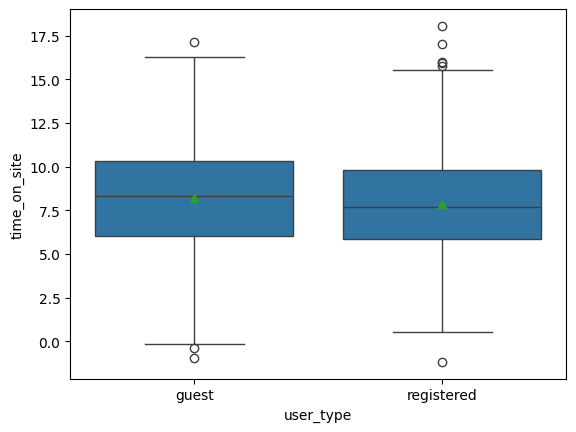

In [86]:
sns.boxplot(
    data=abandon_df, 
    x='user_type', 
    y='time_on_site',
    showmeans=True
)
답04 = 2

#### Q04. 결측치 처리

In [87]:
# inplace=True은 pandas 3.0부터 지원되지 않는다.
# abandon_df['time_on_site'].fillna(abandon_df['time_on_site'].median(), inplace=True)
# abandon_df['cart_value'].fillna(abandon_df['cart_value'].mean(), inplace=True)

abandon_df['time_on_site'] = abandon_df['time_on_site'].fillna(abandon_df['time_on_site'].median())
abandon_df['cart_value'] = abandon_df['cart_value'].fillna(abandon_df['cart_value'].mean())

#### Q05. 범주형 변수 인코딩

In [88]:
abandon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cart_value        1300 non-null   float64
 1   num_items         1300 non-null   int64  
 2   device            1300 non-null   str    
 3   time_on_site      1300 non-null   float64
 4   prev_purchase     1300 non-null   str    
 5   country           1300 non-null   str    
 6   payment_method    1300 non-null   str    
 7   discount_applied  1300 non-null   str    
 8   user_type         1300 non-null   str    
 9   cart_abandon_yn   1300 non-null   int64  
dtypes: float64(2), int64(2), str(6)
memory usage: 101.7 KB


In [89]:
abandon_df["prev_purchase"] = abandon_df["prev_purchase"].map({"Y": 1, "N": 0})
abandon_df["discount_applied"] = abandon_df["discount_applied"].map({"Y": 1, "N": 0}) 
abandon_df["user_type"] = abandon_df["user_type"].map({"registered": 1, "guest": 0})

cat_col = ['device', 'country', 'payment_method']

In [90]:
abandon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cart_value        1300 non-null   float64
 1   num_items         1300 non-null   int64  
 2   device            1300 non-null   str    
 3   time_on_site      1300 non-null   float64
 4   prev_purchase     1300 non-null   int64  
 5   country           1300 non-null   str    
 6   payment_method    1300 non-null   str    
 7   discount_applied  1300 non-null   int64  
 8   user_type         1300 non-null   int64  
 9   cart_abandon_yn   1300 non-null   int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 101.7 KB


In [91]:
incoding_df = pd.get_dummies(
    data=abandon_df,
    columns=cat_col,
    drop_first=True
)

#### Q06. 필요없는 컬럼 제거

In [92]:
# columns=와 axis=1을 동시에 사용하면 오류발생!
# incoding_df.drop(columns=['num_items'], axis=1, inplace=True)

incoding_df.drop(['num_items'], axis=1, inplace=True)

#### Q07. 이상치 제거

In [93]:
# filtering_df = incoding_df.drop(incoding_df[incoding_df['time_on_site']<0].index, axis=0)
filtering_df = incoding_df.drop(incoding_df[incoding_df['time_on_site']<0].index)
filtering_df.reset_index(drop=True, inplace=True)

#### Q08. feature/target 분리

In [97]:
# X = filtering_df.drop(['cart_abandon_yn'], axis=1)
X = filtering_df.drop(columns=['cart_abandon_yn'])
y = filtering_df['cart_abandon_yn']

#### Q09. train/test 데이터 분리

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#### Q10. 데이터 표준화

In [101]:
from sklearn.preprocessing import StandardScaler

In [102]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

#### Q11. 랜덤포레스트 분류 모델 학습

In [103]:
from sklearn.ensemble import RandomForestClassifier

In [104]:
rfc = RandomForestClassifier(
    n_estimators=100, max_depth=7, random_state=42
)

rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

#### Q12. XGBoost 분류 모델 학습

In [105]:
from xgboost import XGBClassifier

In [106]:
xgbc = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
)

xgbc.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

#### Q13. 모델 성능 비교 (accuracy, f1)

In [107]:
from sklearn.metrics import accuracy_score, f1_score

In [114]:
rfc_predict = rfc.predict(X_test)
rfc_accuracy = accuracy_score(y_valid, rfc_predict)
rfc_f1 = f1_score(y_valid, rfc_predict)

xgbc_predict = xgbc.predict(X_test)
xgbc_accuracy = accuracy_score(y_valid, xgbc_predict)
xgbc_f1 = f1_score(y_valid, xgbc_predict)

print(f"rfc_accuracy= {rfc_accuracy:.4f}")
print(f"rfc_f1= {rfc_f1:.4f}")
print(f"xgbc_accuracy= {xgbc_accuracy:.4f}")
print(f"xgbc_f1= {xgbc_f1:.4f}")

rfc_accuracy= 0.6654
rfc_f1= 0.0225
xgbc_accuracy= 0.6385
xgbc_f1= 0.1754


#### Q14. 딥러닝 모델 설계 및 학습

In [115]:
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense 
from tensorflow.keras.utils import to_categorical 

tf.random.set_seed(42)

y_train = to_categorical(y_train, num_classes=2) 
y_valid = to_categorical(y_valid, num_classes=2)

In [121]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=128,
    validation_data=(X_valid, y_valid)
)

d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5386 - loss: 0.7083 - val_accuracy: 0.6692 - val_loss: 4.7131
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6506 - loss: 0.6575 - val_accuracy: 0.6692 - val_loss: 11.1453
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6737 - loss: 0.6452 - val_accuracy: 0.6692 - val_loss: 12.1654
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6737 - loss: 0.6374 - val_accuracy: 0.6692 - val_loss: 11.5619
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6737 - loss: 0.6322 - val_accuracy: 0.6692 - val_loss: 11.1234
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6737 - loss: 0.6284 - val_accuracy: 0.6692 - val_loss: 11.3370
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6766 - loss: 0.6248 - val_accuracy: 0.6692 - val_loss: 11.6764
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6786 - loss: 0.6216 - val_accuracy: 0.6692 - val_loss: 1